# Códigos — Módulo 2: Limpieza y Preparación de Datos 
**Diagnóstico y Predictibilidad | Prof. Robin Sequeira | ULACIT 2026** 
> Continúa desde el notebook de la Semana 01. La tabla ya está cargada como `pdf`. 

### Código 1 — Retomar desde Semana 01

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargamos la tabla igual que en Semana 01
spark_df = spark.table("workspace.diagnosticopredictibilidad.superstore")
pdf = spark_df.toPandas()

# Confirmamos que todo está bien
print("Filas:", pdf.shape[0], "  Columnas:", pdf.shape[1])
pdf.head()

Filas: 51290   Columnas: 25


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Delivery Days,order year,order month
0,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,Oklahoma City,Oklahoma,United States,Central US,USCA,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221,2,0.0,62,40,High,2,2014,11
1,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,Oceania,Asia Pacific,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709,9,0.1,-288,923,Critical,2,2014,2
2,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,Brisbane,Queensland,Australia,Oceania,Asia Pacific,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175,9,0.1,919,915,Medium,1,2014,10
3,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,Berlin,Berlin,Germany,Western Europe,Europe,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892,5,0.1,-96,910,Medium,2,2014,1
4,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Western Africa,Africa,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832,8,0.0,311,903,Critical,1,2014,11


### Código 2 — Crear copia de trabajo

In [0]:
# Siempre trabajamos sobre una copia para proteger el original
df_clean = pdf.copy()
print("Copia lista. Shape:", df_clean.shape)

Copia lista. Shape: (51290, 25)


### Código 3 — Diagnóstico de nulos

In [0]:
nulos = df_clean.isna().mean().sort_values(ascending=False) * 100
print("Columnas con valores nulos:")
print(nulos[nulos > 0].round(2))

Columnas con valores nulos:
Series([], dtype: float64)


### Código 4 — Diagnóstico de duplicados

In [0]:
n_duplicados = df_clean.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 3


### Código 5 — Diagnóstico de cardinalidad

In [0]:
cardinalidad = df_clean.nunique().sort_values(ascending=False)
print("Valores únicos por columna:")
print(cardinalidad)

Valores únicos por columna:
Order ID          25728
Customer ID       17415
Product Name       3788
Product ID         3788
City               3650
Sales              2259
Profit             1604
Ship Date          1464
Order Date         1430
State              1102
Customer Name       796
Shipping Cost       544
Country             165
Discount             27
Region               23
Sub-Category         17
Quantity             14
order month          12
Delivery Days         8
Market                5
Order Priority        4
order year            4
Ship Mode             4
Category              3
Segment               3
dtype: int64


### Código 6 — Eliminar columna con 100% de nulos

In [0]:
df_clean = df_clean.drop(columns=["Postal Code"], errors='ignore')
print("Shape después de eliminar Postal Code:", df_clean.shape)

Shape después de eliminar Postal Code: (51290, 25)


### Código 7 — Mediana vs. promedio con outliers

In [0]:
ventas_ejemplo = [10, 11, 12, 13, 14, 500]

promedio = sum(ventas_ejemplo) / len(ventas_ejemplo)
mediana = sorted(ventas_ejemplo)[len(ventas_ejemplo)//2]

print(f"Promedio: {promedio:.1f}")
print(f"Mediana:  {mediana}")

Promedio: 93.3
Mediana:  13


### Código 8 — Imputar columna numérica con mediana

In [0]:
df_demo = df_clean.copy()

df_demo.loc[0, "Sales"] = np.nan

print("Nulos en Sales antes:", df_demo["Sales"].isna().sum())

mediana_sales = df_demo["Sales"].median()
df_demo["Sales"] = df_demo["Sales"].fillna(mediana_sales)

print("Nulos en Sales después:", df_demo["Sales"].isna().sum())
print(f"Valor imputado: {mediana_sales:.2f}")

Nulos en Sales antes: 1
Nulos en Sales después: 0
Valor imputado: 85.00


### Código 9 — Imputar columna categórica con moda

In [0]:
df_demo.loc[5, "Ship Mode"] = np.nan

print("Nulos en Ship Mode antes:", df_demo["Ship Mode"].isna().sum())

moda_ship = df_demo["Ship Mode"].mode()[0]
df_demo["Ship Mode"] = df_demo["Ship Mode"].fillna(moda_ship)

print("Nulos en Ship Mode después:", df_demo["Ship Mode"].isna().sum())
print(f"Moda usada: {moda_ship}")

Nulos en Ship Mode antes: 1
Nulos en Ship Mode después: 0
Moda usada: Standard Class


### Código 10 — Boxplot de ventas

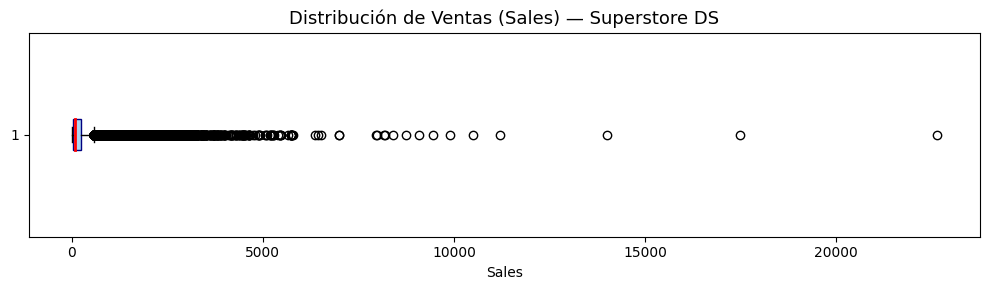

In [0]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot(df_clean["Sales"].dropna(), vert=False, patch_artist=True,
           boxprops=dict(facecolor="#AED6F1", color="navy"), # [cite: 5]
           medianprops=dict(color="red", linewidth=2))
ax.set_title("Distribución de Ventas (Sales) — Superstore DS", fontsize=13)
ax.set_xlabel("Sales")
plt.tight_layout()
plt.show()

### Código 11 — Calcular límites IQR

In [0]:
Q1 = df_clean["Sales"].quantile(0.25)
Q3 = df_clean["Sales"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")

Q1: 30.00
Q3: 251.00
IQR: 221.00
Limite inferior: -301.50
Limite superior: 582.50


### Código 12 — Detectar outliers

In [0]:
outliers = df_clean[
    (df_clean["Sales"] < limite_inferior) |
    (df_clean["Sales"] > limite_superior) # [cite: 6]
]

print(f"Total de outliers: {len(outliers)}")
print(f"Porcentaje del dataset: {len(outliers)/len(df_clean)*100:.1f}%")
outliers[["Order ID", "Category", "Sales"]].head(10)

Total de outliers: 5641
Porcentaje del dataset: 11.0%


,Order ID,Category,Sales
1,IN-2014-JR162107-41675,Furniture,3709
2,IN-2014-CR127307-41929,Technology,5175
3,ES-2014-KM1637548-41667,Technology,2892
4,SG-2014-RH9495111-41948,Technology,2832
5,IN-2014-JM156557-41818,Technology,2862
6,IN-2012-TS2134092-41219,Furniture,1822
7,IN-2013-MB1808592-41378,Furniture,5244
11,ID-2013-AJ107801-41383,Furniture,4626
12,SA-2012-MM7260110-41269,Technology,2616
13,MX-2013-VF2171518-41591,Furniture,2221


### Código 13 — Opciones para manejar outliers

In [0]:
# Opción A: eliminar outliers
df_sin_outliers = df_clean[
    (df_clean["Sales"] >= limite_inferior) &
    (df_clean["Sales"] <= limite_superior)
]
print(f"Sin outliers: {df_sin_outliers.shape[0]} filas")

# Opción B: conservar (no hacer nada)
print(f"Original: {df_clean.shape[0]} filas")

# Opción C: winsorizar (recortar en los límites)
df_winsor = df_clean.copy()
df_winsor["Sales"] = df_winsor["Sales"].clip(lower=limite_inferior, upper=limite_superior)
print("Max Sales después de winsorizar:", df_winsor["Sales"].max().round(2))

Sin outliers: 45649 filas
Original: 51290 filas
Max Sales después de winsorizar: 582.5


### Código 14 — Normalizar nombres de columnas

In [0]:
print("ANTES:")
print(df_clean.columns.tolist())

df_clean.columns = (df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print("\nDESPUÉS:")
print(df_clean.columns.tolist())

ANTES:
['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Region', 'Market', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority', 'Delivery Days', 'order year', 'order month']

DESPUÉS:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'city', 'state', 'country', 'region', 'market', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'delivery_days', 'order_year', 'order_month']


### Código 15 — Ver tipos de datos

In [0]:
print(df_clean.dtypes)

order_id           object
order_date         object
ship_date          object
ship_mode          object
customer_id        object
customer_name      object
segment            object
city               object
state              object
country            object
region             object
market             object
product_id         object
category           object
sub_category       object
product_name       object
sales               int64
quantity            int64
discount          float64
profit              int64
shipping_cost       int64
order_priority     object
delivery_days       int64
order_year          int64
order_month         int64
dtype: object


### Código 16 — Convertir fechas y crear variable derivada 

In [0]:
df_clean["order_date"] = pd.to_datetime(df_clean["order_date"], errors="coerce")
df_clean["ship_date"]  = pd.to_datetime(df_clean["ship_date"],  errors="coerce")

print(df_clean[["order_date", "ship_date"]].dtypes)

df_clean["dias_envio"] = (df_clean["ship_date"] - df_clean["order_date"]).dt.days
print("\nDías de envío (primeras 5 filas):")
print(df_clean["dias_envio"].head())

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object

Días de envío (primeras 5 filas):
0    2
1    2
2    1
3    2
4    1
Name: dias_envio, dtype: int64


REFLEXION FINAL para el portafolio:

1. ¿Qué aprendí?

Que los algoritmos no sirven de nada si los datos vienen sucios ("Garbage In, Garbage Out"). Hacer un diagnóstico rápido del dataset usando isna(), duplicated() y nunique() para entender a qué me enfrento. Además, vi cómo imputar datos correctamente (mediana para numéricas y moda para categóricas) y a usar la regla del IQR para detectar outliers.  

2. ¿Qué me costó más?

Definir la línea entre lo técnico y el contexto del negocio. porque decidir si un outlier se elimina porque es un error o se conserva porque es una venta extraordinaria requiere de criterio analítico y conocimiento del negocio.  

3. ¿Dónde podría aplicar esto en mi realidad laboral?

Me sirve para las montar un prototipo con data de la empresa donde laboro, como un PoC predictivo, al trabajar con un dataset de eventos extraídos de Google Analytics, puedo aplicar este flujo directamente en Databricks para limpiar dicha data.
